STL分解による予備分析を行う。

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.seasonal import STL
import seaborn as sns
import numpy as np

In [8]:
df = pd.read_csv('../data/Transport_amount_data.csv')
df['label'] = pd.to_datetime(df['label'])
df

,label,year,month,Transport_tonnage,number_parcels,Number_companies_1,Number_companies_2
0,2002-04-01,2002,4,5933686,218721,26,20
1,2002-05-01,2002,5,5474539,208283,26,20
2,2002-06-01,2002,6,5430018,218633,26,20
3,2002-07-01,2002,7,6345951,271764,26,20
4,2002-08-01,2002,8,5354671,217650,26,20
...,...,...,...,...,...,...,...
239,2022-03-01,2022,3,6118588,426615,24,14
240,2022-04-01,2022,4,5727532,387559,24,14
241,2022-05-01,2022,5,5102766,380692,24,14
242,2022-06-01,2022,6,5723215,411429,24,14


In [9]:
df = df.set_index('label')

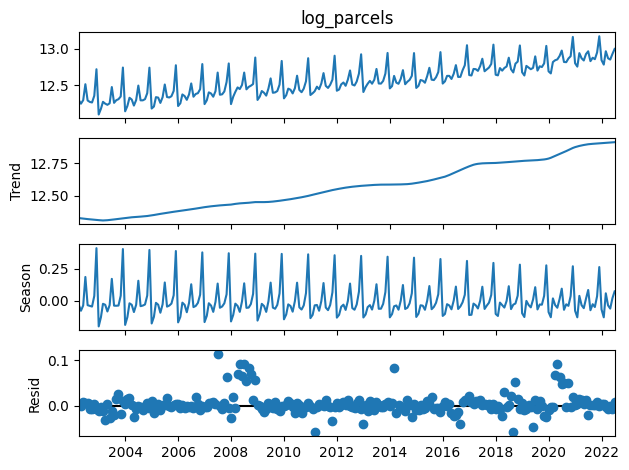

label
2002-04-01    0.000348
2002-05-01   -0.000009
2002-06-01    0.008767
2002-07-01    0.005000
2002-08-01    0.006107
                ...   
2022-03-01   -0.003791
2022-04-01   -0.006836
2022-05-01   -0.000293
2022-06-01   -0.006404
2022-07-01    0.007786
Freq: MS, Name: resid, Length: 244, dtype: float64

In [ ]:
# データの頻度を「月次(Month Start)」に設定（エラー回避のため推奨）
df.index.freq = 'MS' 

# 原系列は振幅が拡大している（乗法モデル的）ため、対数変換して加法モデル（STL）に適応させる
# ※状態空間モデルでも対数を用いたのと同じ理由です
df['log_parcels'] = np.log(df['number_parcels'])

stl = STL(df['log_parcels'], period=12, robust=True)
res = stl.fit()

stl_resid = res.resid
stl_resid

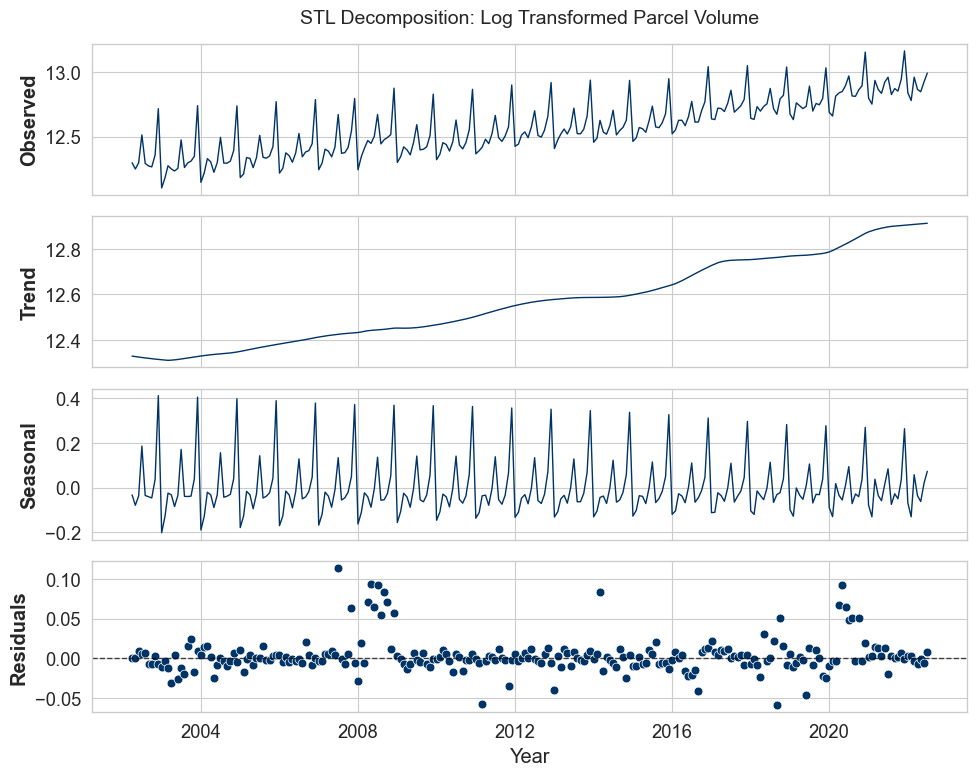

In [12]:
sns.set_context("paper", font_scale=1.5) 
sns.set_style("whitegrid") # 白背景＋グリッド

# 配色（落ち着いた紺色などを使用）
main_color = "#003366"  # 濃い青（論文で印刷してもきれいに出ます）
resid_color = "#CC0000" # 残差の強調用（必要なら変更可）

# -------------------------------------------------------
# 2. 描画キャンバスの作成（4段組み）
# -------------------------------------------------------
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

# データ（resオブジェクト）から各成分を取得して描画
# ※ res は前のステップの stl.fit() の結果です

# --- (1) 原系列 (Observed) ---
sns.lineplot(data=res.observed, ax=axes[0], color=main_color, linewidth=1)
axes[0].set_ylabel('Observed', fontweight='bold')
axes[0].set_title('STL Decomposition: Log Transformed Parcel Volume', fontsize=14, pad=15)

# --- (2) トレンド (Trend) ---
sns.lineplot(data=res.trend, ax=axes[1], color=main_color, linewidth=1)
axes[1].set_ylabel('Trend', fontweight='bold')

# --- (3) 季節性 (Seasonal) ---
sns.lineplot(data=res.seasonal, ax=axes[2], color=main_color, linewidth=1)
axes[2].set_ylabel('Seasonal', fontweight='bold')

# --- (4) 残差 (Residuals) ---
# 残差は「点（scatter）」で描画するのが一般的です
sns.scatterplot(data=res.resid, ax=axes[3], color=main_color, s=40, edgecolor="white", linewidth=0.5)
# 0のラインを引く（基準線）
axes[3].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
axes[3].set_ylabel('Residuals', fontweight='bold')
axes[3].set_xlabel('Year') # 最後の段だけX軸ラベルを入れる

# -------------------------------------------------------
# 3. 仕上げ
# -------------------------------------------------------
# 軸ラベルの調整（不要な日付ラベルの間引きなど）
plt.tight_layout()

# 保存（高解像度で行う）
# plt.savefig("stl_decomposition_professional.png", dpi=300, bbox_inches='tight')

plt.show()

In [14]:
# 2. ダミー変数の作成（論文の定義に基づく）
# -------------------------------------------------------
# 日付インデックスを使ってブールマスクを作成し、0/1に変換(astype(int))します

# (1) hike_dummy: 2017年10月 - 2019年12月
df['hike_dummy'] = 0
df.loc['2017-10-01':'2019-12-01', 'hike_dummy'] = 1

# (2) covid_main: 2020年03月 - 最後まで
df['covid_main'] = 0
df.loc['2020-03-01':, 'covid_main'] = 1

# (3) covid_wave1: 2020年04月 - 2020年05月
df['covid_wave1'] = 0
df.loc['2020-04-01':'2020-05-01', 'covid_wave1'] = 1

# (4) covid_2021: 2021年01月 - 2021年09月
df['covid_2021'] = 0
df.loc['2021-01-01':'2021-09-01', 'covid_2021'] = 1

# 確認
print("作成されたダミー変数の確認:")
print(df[['hike_dummy', 'covid_main', 'covid_wave1', 'covid_2021']].tail())

# -------------------------------------------------------
# 3. STL分解と残差の抽出
# -------------------------------------------------------
stl = STL(df['log_parcels'], period=12, robust=True)
res = stl.fit()
stl_resid = res.resid  # これが目的変数になります

# -------------------------------------------------------
# 4. OLS（重回帰分析）の実行
# -------------------------------------------------------
# 目的変数
Y = stl_resid

# 説明変数（定数項を追加）
features = ['hike_dummy', 'covid_main', 'covid_wave1', 'covid_2021']
X = df[features]
X = sm.add_constant(X)

# モデル作成と学習
model = sm.OLS(Y, X).fit()

# 結果の表示（詳細）
print("\n=== OLS Regression Results ===")
print(model.summary())

# -------------------------------------------------------
# 5. 論文用の表として整形（ここが重要です）
# -------------------------------------------------------
# 結果から必要な情報（係数、標準誤差、t値、p値）を抽出してDataFrameにする
results_table = pd.DataFrame({
    'Coefficient': model.params,
    'Std. Error': model.bse,
    't-value': model.tvalues,
    'p-value': model.pvalues,
    'Significant': model.pvalues < 0.05  # 5%有意かどうかのフラグ
})

# 小数点の桁数を丸める（論文掲載用）
results_table = results_table.round(4)

print("\n=== 論文掲載用テーブル（整形後） ===")
results_table

作成されたダミー変数の確認:
            hike_dummy  covid_main  covid_wave1  covid_2021
label                                                      
2022-03-01           0           1            0           0
2022-04-01           0           1            0           0
2022-05-01           0           1            0           0
2022-06-01           0           1            0           0
2022-07-01           0           1            0           0

=== OLS Regression Results ===
                            OLS Regression Results                            
Dep. Variable:                  resid   R-squared:                       0.111
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                     7.490
Date:                Sat, 22 Nov 2025   Prob (F-statistic):           1.06e-05
Time:                        16:28:10   Log-Likelihood:                 590.02
No. Observations:                 244   AIC:               

,Coefficient,Std. Error,t-value,p-value,Significant
const,0.0029,0.0016,1.8496,0.0656,False
hike_dummy,-0.0060,0.0045,-1.3329,0.1838,False
covid_main,0.0097,0.0054,1.8009,0.0730,False
covid_wave1,0.0667,0.0162,4.1112,0.0001,True
covid_2021,-0.0091,0.0089,-1.0206,0.3085,False
